In [19]:
from __future__ import annotations

import ast
import math
from pathlib import Path
from typing import Any, Literal

import pandas as pd


AggregationMode = Literal["mean", "median", "best", "raw"]


RUN_SPECIFIC_COLUMNS = {
    "run_id",
    "duration_seconds",
    "finished_at",
    "processor",
    "hostname",
    "total_ram_gb",
    "physical_cores",
    "logical_cores",
    "python_version",
    "peak_ram_mb",
    "benchmark_repeat_idx",
    "sdp_seed",
    "sdp_seed.1",
    "lasserre_level",
    "initial_solver_level_M",
    "sdp_objective_value_step1",
    "sdp_objective_value_king_normalized_step1",
    "algorithm17_actual_energy",
    "algorithm17_lower_bound_energy",
    "initial_ws_energy_prodStates_step2",
    "initial_sdp_statevector_energy",
    "initial_sdp_statevec_ratio",
    "initial_ws_energy_010101",
    "QAOA_improvement_over_SDP_statevectorEnergy",
    "QAOA_improvement_over_SDP_prodStatesEnergy",
    "result",
    "result_010101",
    "approx_ratio",
    "approx_ratio_010101",
    "diff. approx. ratio",
    "sdp ws greater",
}


def _is_nan(x: Any) -> bool:
    try:
        return bool(pd.isna(x))
    except Exception:
        return False


def _safe_float(x: Any) -> float | None:
    if x is None or _is_nan(x):
        return None
    try:
        return float(x)
    except Exception:
        return None


def _parse_literal(value: Any, default: Any = None) -> Any:
    if value is None or _is_nan(value):
        return default
    if not isinstance(value, str):
        return value

    value = value.strip()
    if not value:
        return default

    try:
        return ast.literal_eval(value)
    except Exception:
        return default


def _canonical_edges(edges_raw: Any) -> tuple[tuple[int, int], ...]:
    edges = _parse_literal(edges_raw, default=[])
    canonical = []

    for i, j in edges:
        i, j = int(i), int(j)
        canonical.append((min(i, j), max(i, j)))

    return tuple(sorted(canonical))


def _canonical_edge_weight_tuple(row: pd.Series) -> tuple[tuple[tuple[int, int], float], ...]:
    edges = _canonical_edges(row.get("edges"))
    weights_raw = row.get("weights")

    weights = _parse_literal(weights_raw, default=None)
    if weights is None:
        weights = [1.0] * len(edges)

    if len(weights) != len(edges):
        raise ValueError(
            f"weights length {len(weights)} does not match edges length {len(edges)} "
            f"for run_id={row.get('run_id')}"
        )

    edge_weights = [(edge, float(weight)) for edge, weight in zip(edges, weights)]
    return tuple(sorted(edge_weights, key=lambda x: x[0]))


def _edge_weight_dict(edge_weight_tuple: tuple[tuple[tuple[int, int], float], ...]) -> dict[tuple[int, int], float]:
    return {edge: weight for edge, weight in edge_weight_tuple}


def _normalise_key_value(value: Any) -> Any:
    if _is_nan(value):
        return None

    if isinstance(value, str):
        stripped = value.strip()
        parsed = _parse_literal(stripped, default=stripped)
        if isinstance(parsed, list):
            return tuple(parsed)
        if isinstance(parsed, dict):
            return tuple(sorted(parsed.items()))
        return parsed

    if isinstance(value, list):
        return tuple(value)

    if isinstance(value, dict):
        return tuple(sorted(value.items()))

    if isinstance(value, float) and value.is_integer():
        return int(value)

    return value


def _benchmark_key(row: pd.Series, extra_setting_columns: list[str] | None = None) -> tuple:
    graph_type = str(row.get("graph_generation_type", "unknown")).lower()
    n_vertices = int(row["n"])
    n_edges = int(row["m"])
    edge_weight_tuple = _canonical_edge_weight_tuple(row)

    default_setting_columns = [
        "p",
        "precision/iterations",
        "parameter_vector",
        "optimiser",
        "optimiser_use_heuristic",
        "heuristic_optimiser_iterations",
        "heuristic_optimiser_sampleSize",
        "circuit_type",
        "learning_rate_adam",
        "warm_start",
        "warm_start_mode",
        "singlet_injection",
        "start_index_singlet",
        "warm_start_corr_strength",
        "warm_start_corr_repeats",
        "compare_with_010101",
        "init_QAOAparams_close_to_zero",
        "use_correlations_as_initial_params",
        "weighted",
        "hog_graph_index",
    ]

    setting_columns = extra_setting_columns or default_setting_columns

    settings_tuple = tuple(
        (col, _normalise_key_value(row.get(col)))
        for col in setting_columns
        if col in row.index and col not in RUN_SPECIFIC_COLUMNS
    )

    return (
        graph_type,
        n_vertices,
        n_edges,
        edge_weight_tuple,
        settings_tuple,
    )


def _seed_key(row: pd.Series) -> tuple:
    """
    Key identifying one sampled repeat within a benchmark setting.
    Prefer sdp_seed. Fall back to benchmark_repeat_idx.
    """
    seed = _normalise_key_value(row.get("sdp_seed"))
    repeat_idx = _normalise_key_value(row.get("benchmark_repeat_idx"))

    if seed is not None:
        return ("sdp_seed", seed)

    if repeat_idx is not None:
        return ("benchmark_repeat_idx", repeat_idx)

    return ("anonymous_sample", None)


def _filter_to_common_seeds(
    g1: pd.DataFrame | None,
    g2: pd.DataFrame | None,
) -> tuple[pd.DataFrame | None, pd.DataFrame | None, list[tuple]]:
    if g1 is None or g2 is None:
        return None, None, []

    g1 = g1.copy()
    g2 = g2.copy()

    g1["_sample_key"] = g1.apply(_seed_key, axis=1)
    g2["_sample_key"] = g2.apply(_seed_key, axis=1)

    common_sample_keys = sorted(set(g1["_sample_key"]) & set(g2["_sample_key"]), key=str)

    g1_common = g1[g1["_sample_key"].isin(common_sample_keys)].copy()
    g2_common = g2[g2["_sample_key"].isin(common_sample_keys)].copy()

    return g1_common, g2_common, common_sample_keys


def _graph_instance_from_key(key: tuple) -> dict[str, Any]:
    graph_type, n_vertices, n_edges, edge_weight_tuple, settings_tuple = key

    return {
        "graph_type": graph_type,
        "#vertices": n_vertices,
        "#edges": n_edges,
        "#qaoa_layers": dict(settings_tuple).get("p"),
        #"edge_weight_dict": _edge_weight_dict(edge_weight_tuple),
        ##"settings": dict(settings_tuple),
    }


def _optimal_value_from_row(row: pd.Series) -> float | None:
    optimal = _safe_float(row.get("optimal_result"))
    if optimal is not None:
        return optimal

    result = _safe_float(row.get("result"))
    approx = _safe_float(row.get("approx_ratio"))

    if result is not None and approx not in (None, 0.0):
        return result / approx

    return None


def _series_stats(values: list[float | None], mode: AggregationMode = "mean") -> dict[str, Any]:
    clean = [float(v) for v in values if v is not None and not math.isnan(float(v))]

    if not clean:
        return {
            "value": None,
            "min": None,
            "mean": None,
            "median": None,
            "max": None,
            "std": None,
            "count": 0,
            "raw": [],
        }

    s = pd.Series(clean, dtype=float)

    if mode == "mean":
        value = float(s.mean())
    elif mode == "median":
        value = float(s.median())
    elif mode == "best":
        value = float(s.max())
    elif mode == "raw":
        value = clean
    else:
        raise ValueError(f"Unknown aggregation mode: {mode}")

    return {
        "value": value,
        "min": float(s.min()),
        "mean": float(s.mean()),
        "median": float(s.median()),
        "max": float(s.max()),
        "std": float(s.std(ddof=1)) if len(clean) > 1 else 0.0,
        "count": int(len(clean)),
        "raw": clean,
    }


def _load_and_validate(path: str | Path, expected_lasserre_level: int) -> pd.DataFrame:
    df = pd.read_csv(path, skipinitialspace=True)

    if "lasserre_level" not in df.columns:
        raise ValueError(f"{path} has no lasserre_level column.")

    levels = set(pd.to_numeric(df["lasserre_level"], errors="coerce").dropna().astype(int))
    if expected_lasserre_level not in levels:
        raise ValueError(
            f"{path} does not contain lasserre_level={expected_lasserre_level}. "
            f"Found levels: {sorted(levels)}"
        )

    df = df[pd.to_numeric(df["lasserre_level"], errors="coerce").astype("Int64") == expected_lasserre_level].copy()
    return df


def _group_rows(df: pd.DataFrame, extra_setting_columns: list[str] | None = None) -> dict[tuple, pd.DataFrame]:
    grouped: dict[tuple, list[int]] = {}

    for idx, row in df.iterrows():
        key = _benchmark_key(row, extra_setting_columns=extra_setting_columns)
        grouped.setdefault(key, []).append(idx)

    return {key: df.loc[idxs].copy() for key, idxs in grouped.items()}


def aggregate_lasserre_qaoa_results(
    lasserre1_csv: str | Path,
    lasserre2_csv: str | Path,
    *,
    only_common: bool = True,
    only_common_samples: bool = True,
    aggregation_mode: AggregationMode = "mean",
    extra_setting_columns: list[str] | None = None,
) -> dict[tuple, dict[str, Any]]:
    df1 = _load_and_validate(lasserre1_csv, expected_lasserre_level=1)
    df2 = _load_and_validate(lasserre2_csv, expected_lasserre_level=2)

    groups1 = _group_rows(df1, extra_setting_columns=extra_setting_columns)
    groups2 = _group_rows(df2, extra_setting_columns=extra_setting_columns)

    keys = set(groups1) & set(groups2) if only_common else set(groups1) | set(groups2)
    keys = sorted(keys, key=str)

    aggregated: dict[tuple, dict[str, Any]] = {}

    for key in keys:
        g1_original = groups1.get(key)
        g2_original = groups2.get(key)

        if only_common_samples:
            g1, g2, common_sample_keys = _filter_to_common_seeds(g1_original, g2_original)

            if only_common and len(common_sample_keys) == 0:
                continue
        else:
            g1 = g1_original
            g2 = g2_original
            common_sample_keys = []

        n_l1_total = 0 if g1_original is None else len(g1_original)
        n_l2_total = 0 if g2_original is None else len(g2_original)

        n_l1_used = 0 if g1 is None else len(g1)
        n_l2_used = 0 if g2 is None else len(g2)
        n_common_samples = len(common_sample_keys) if only_common_samples else min(n_l1_used, n_l2_used)

        optimal_candidates: list[float | None] = []
        if g1 is not None:
            optimal_candidates.extend(_optimal_value_from_row(row) for _, row in g1.iterrows())
        if g2 is not None:
            optimal_candidates.extend(_optimal_value_from_row(row) for _, row in g2.iterrows())

        graph_instance = _graph_instance_from_key(key)
        """graph_instance["samples"] = {
            "common_used": n_common_samples,
            "lasserre1_used": n_l1_used,
            "lasserre2_used": n_l2_used,
            "lasserre1_total_available": n_l1_total,
            "lasserre2_total_available": n_l2_total,
            #"sample_keys_used": common_sample_keys,
        }"""

        aggregated[key] = {
            "graph_instance": graph_instance,
            "optimal_value": _series_stats(optimal_candidates, mode=aggregation_mode),

            "lasserre1_value_step1": _series_stats(
                [] if g1 is None else [_safe_float(x) for x in g1["sdp_objective_value_step1"]],
                mode=aggregation_mode,
            ),
            "lasserre2_value_step1": _series_stats(
                [] if g2 is None else [_safe_float(x) for x in g2["sdp_objective_value_king_normalized_step1"]],
                mode=aggregation_mode,
            ),

            "lasserre1_value_after_gp_rounding_step2": _series_stats(
                [] if g1 is None else [_safe_float(x) for x in g1["initial_ws_energy_prodStates_step2"]],
                mode=aggregation_mode,
            ),
            "lasserre2_value_after_gp_rounding_step2": _series_stats(
                [] if g2 is None else [_safe_float(x) for x in g2["initial_ws_energy_prodStates_step2"]],
                mode=aggregation_mode,
            ),

            "lasserre2_value_after_rotations_step10": _series_stats(
                [] if g2 is None else [_safe_float(x) for x in g2["algorithm17_actual_energy"]],
                mode=aggregation_mode,
            ),

            "lasserre1_qaoa_result": _series_stats(
                [] if g1 is None else [_safe_float(x) for x in g1["result"]],
                mode=aggregation_mode,
            ),
            "lasserre2_qaoa_result": _series_stats(
                [] if g2 is None else [_safe_float(x) for x in g2["result"]],
                mode=aggregation_mode,
            ),

            "present_in_lasserre1": g1_original is not None,
            "present_in_lasserre2": g2_original is not None,

            "n_rows_lasserre1": n_l1_used,
            "n_rows_lasserre2": n_l2_used,
            "n_common_samples_used": n_common_samples,

            "n_rows_lasserre1_total_available": n_l1_total,
            "n_rows_lasserre2_total_available": n_l2_total,

            "common_sample_keys": common_sample_keys,
        }

    return aggregated

In [20]:
from pathlib import Path
import json
import math
import pandas as pd


# -----------------------------
# Input / output paths
# -----------------------------
lasserre1_csv = Path("/Users/julian/University/MasterThesis/QAOA/Code/qaoa_results_adam_20260603_101922_pid49945.csv")
lasserre2_csv = Path("/Users/julian/University/MasterThesis/QAOA/Code/qaoa_results_adam_20260603_110426_pid43695.csv")

output_csv = Path("aggregated_lasserre1_vs_lasserre2.csv")


# -----------------------------
# Compact cell helpers
# -----------------------------
def make_json_safe(obj):
    """
    Recursively convert Python objects into JSON-safe objects.
    In particular, tuple dict keys like (0, 1) become strings like "0-1".
    """
    if isinstance(obj, dict):
        safe = {}
        for k, v in obj.items():
            if isinstance(k, tuple):
                key = "-".join(map(str, k))
            else:
                key = str(k)
            safe[key] = make_json_safe(v)
        return safe

    if isinstance(obj, tuple):
        return [make_json_safe(x) for x in obj]

    if isinstance(obj, list):
        return [make_json_safe(x) for x in obj]

    if isinstance(obj, (pd.Series, pd.Index)):
        return [make_json_safe(x) for x in obj.tolist()]

    if pd.isna(obj) if not isinstance(obj, (list, tuple, dict)) else False:
        return None

    return obj


def json_cell(obj) -> str:
    return json.dumps(make_json_safe(obj), sort_keys=False)


def stats_cell(stats: dict, digits: int | None = 10) -> str:
    payload = {
        "min": stats.get("min"),
        "mean": stats.get("mean"),
        "median": stats.get("median"),
        "max": stats.get("max"),
        "std": stats.get("std"),
        "count": stats.get("count", 0),
    }

    if digits is not None:
        for key in ("min", "mean", "median", "max", "std"):
            if payload[key] is not None and not pd.isna(payload[key]):
                payload[key] = round(float(payload[key]), digits)

    return json_cell(payload)


def ratio_stats_cell(metric_stats: dict, optimal_stats: dict, digits: int | None = 10) -> str:
    metric_raw = metric_stats.get("raw", [])
    optimal_raw = optimal_stats.get("raw", [])

    metric_clean = [float(x) for x in metric_raw if x is not None and not math.isnan(float(x))]
    optimal_clean = [float(x) for x in optimal_raw if x is not None and not math.isnan(float(x)) and float(x) != 0.0]

    ratios = []
    if metric_clean:
        # If there are more optimal values than metric values, use the first len(metric_clean)
        if len(optimal_clean) >= len(metric_clean):
            ratios = [m / optimal_clean[i] for i, m in enumerate(metric_clean)]
        # If the lengths differ and no direct matching is possible, fall back on mean ratios
        elif metric_stats.get("mean") is not None and optimal_stats.get("mean") not in (None, 0.0):
            ratios = [float(metric_stats["mean"]) / float(optimal_stats["mean"])]
    return stats_cell(_series_stats(ratios), digits=digits)


# -----------------------------
# Aggregate over intersecting sampled seeds/repeats
# -----------------------------
aggregated = aggregate_lasserre_qaoa_results(
    lasserre1_csv=lasserre1_csv,
    lasserre2_csv=lasserre2_csv,
    only_common=True,           # only benchmark settings that exist in both CSVs
    only_common_samples=True,   # only seeds/repeats that exist in both CSVs
    aggregation_mode="mean",
)


# -----------------------------
# One row per benchmark setting
# -----------------------------
rows = []

for benchmark_key, values in aggregated.items():
    graph_instance = values["graph_instance"]
    optimal_stats = values["optimal_value"]

    row = {
        # First column contains graph, settings, and actually used sample intersection.
        "graph_instance": json_cell(graph_instance),

        # Extra visible sample summary for convenience.
        "sample_summary": json_cell({
            "common_used": values["n_common_samples_used"],
            "lasserre1_used": values["n_rows_lasserre1"],
            "lasserre2_used": values["n_rows_lasserre2"],
            "lasserre1_total_available": values["n_rows_lasserre1_total_available"],
            "lasserre2_total_available": values["n_rows_lasserre2_total_available"],
        }),

        # Requested variables, each as a compact stats dict.
        "Optimal value from Vincenzo": stats_cell(values["optimal_value"]),

        # Step 1 energies (should be upper bounds)
        "Lasserre 1 Step 1 energy from relaxation (before GW rounding)": stats_cell(values["lasserre1_value_step1"]),
        "Lasserre 2 Step 1 energy from relaxation (before GW rounding)": stats_cell(values["lasserre2_value_step1"]),

        # Step 2 energies after GP rounding (for lasserre 1 this is also the final result)
        "Lasserre 1 Step 2 energy after GP rounding": stats_cell(
            values["lasserre1_value_after_gp_rounding_step2"]
        ),
        "Lasserre 2 Step 2 energy after GP rounding": stats_cell(
            values["lasserre2_value_after_gp_rounding_step2"]
        ),

        # Lasserre 2 final energy after GP + rotations
        "Lasserre 2 Final energy after GP + rotations": stats_cell(
            values["lasserre2_value_after_rotations_step10"]
        ),

        # QAOA results after using SDP vector as warm start
        "Lasserre 1 QAOA result after using SDP vector as warm start": stats_cell(values["lasserre1_qaoa_result"]),
        "Lasserre 2 QAOA result after using SDP vector as warm start": stats_cell(values["lasserre2_qaoa_result"]),

        # Optional approximation ratios, also compact dicts.
        "Lasserre 1 Step 1 SDP energy approx. ratio (before GW rounding)": ratio_stats_cell(
            values["lasserre1_value_step1"], optimal_stats
        ),
        "Lasserre 2 Step 1 SDP energy approx. ratio (before GW rounding)": ratio_stats_cell(
            values["lasserre2_value_step1"], optimal_stats
        ),
        "Lasserre 1 Step 2 GP GW-rounding energy approx. ratio": ratio_stats_cell(
            values["lasserre1_value_after_gp_rounding_step2"], optimal_stats
        ),
        "Lasserre 2 Step 2 GP GW-rounding energy approx. ratio": ratio_stats_cell(
            values["lasserre2_value_after_gp_rounding_step2"], optimal_stats
        ),
        "Lasserre 2 Final energy approx. ratio (after GP + rotations)": ratio_stats_cell(
            values["lasserre2_value_after_rotations_step10"], optimal_stats
        ),
        "Lasserre 1 QAOA approx. ratio": ratio_stats_cell(
            values["lasserre1_qaoa_result"], optimal_stats
        ),
        "Lasserre 2 QAOA approx. ratio": ratio_stats_cell(
            values["lasserre2_qaoa_result"], optimal_stats
        ),
    }

    rows.append(row)


comparison_df = pd.DataFrame(rows)


# Stable ordering using values inside graph_instance.
def _sort_key(row):
    gi = json.loads(row["graph_instance"])
    return (
        gi.get("type", ""),
        gi.get("n", -1),
        gi.get("m", -1),
        str(gi.get("settings", "")),
    )


if not comparison_df.empty:
    comparison_df = (
        comparison_df
        .assign(_sort_key=comparison_df.apply(_sort_key, axis=1))
        .sort_values("_sort_key")
        .drop(columns="_sort_key")
        .reset_index(drop=True)
    )

comparison_df.to_csv(output_csv, index=False)

print(f"Wrote {len(comparison_df)} benchmark settings to {output_csv}")
comparison_df.head()

Wrote 6 benchmark settings to aggregated_lasserre1_vs_lasserre2.csv


,graph_instance,sample_summary,Optimal value from Vincenzo,Lasserre 1 Step 1 energy from relaxation (before GW rounding),Lasserre 2 Step 1 energy from relaxation (before GW rounding),Lasserre 1 Step 2 energy after GP rounding,Lasserre 2 Step 2 energy after GP rounding,Lasserre 2 Final energy after GP + rotations,Lasserre 1 QAOA result after using SDP vector as warm start,Lasserre 2 QAOA result after using SDP vector as warm start,Lasserre 1 Step 1 SDP energy approx. ratio (before GW rounding),Lasserre 2 Step 1 SDP energy approx. ratio (before GW rounding),Lasserre 1 Step 2 GP GW-rounding energy approx. ratio,Lasserre 2 Step 2 GP GW-rounding energy approx. ratio,Lasserre 2 Final energy approx. ratio (after GP + rotations),Lasserre 1 QAOA approx. ratio,Lasserre 2 QAOA approx. ratio
0,"{""graph_type"": ""line"", ""#vertices"": 2, ""#edges...","{""common_used"": 100, ""lasserre1_used"": 100, ""l...","{""min"": 1.0, ""mean"": 1.0, ""median"": 1.0, ""max""...","{""min"": 0.9999999999, ""mean"": 0.9999999999, ""m...","{""min"": 0.999999996, ""mean"": 0.999999996, ""med...","{""min"": 0.4999999997, ""mean"": 0.5, ""median"": 0...","{""min"": 0.5, ""mean"": 0.5, ""median"": 0.5, ""max""...","{""min"": 0.5004716833, ""mean"": 0.6193675471, ""m...","{""min"": 0.5, ""mean"": 0.6708299742, ""median"": 0...","{""min"": 0.5982665494, ""mean"": 0.7686794807, ""m...","{""min"": 0.9999999999, ""mean"": 0.9999999999, ""m...","{""min"": 0.999999996, ""mean"": 0.999999996, ""med...","{""min"": 0.4999999997, ""mean"": 0.5, ""median"": 0...","{""min"": 0.5, ""mean"": 0.5, ""median"": 0.5, ""max""...","{""min"": 0.5004716833, ""mean"": 0.6193675471, ""m...","{""min"": 0.5, ""mean"": 0.6708299742, ""median"": 0...","{""min"": 0.5982665494, ""mean"": 0.7686794807, ""m..."
1,"{""graph_type"": ""line"", ""#vertices"": 3, ""#edges...","{""common_used"": 100, ""lasserre1_used"": 100, ""l...","{""min"": 1.5, ""mean"": 1.5, ""median"": 1.5, ""max""...","{""min"": 1.9999999987, ""mean"": 1.9999999987, ""m...","{""min"": 1.4999999997, ""mean"": 1.4999999997, ""m...","{""min"": 0.9999999943, ""mean"": 0.9999999996, ""m...","{""min"": 0.3365683354, ""mean"": 0.8221251176, ""m...","{""min"": 0.370046554, ""mean"": 0.917249156, ""med...","{""min"": 1.0017366077, ""mean"": 1.3266585864, ""m...","{""min"": 0.6708308664, ""mean"": 1.1513088658, ""m...","{""min"": 1.3333333325, ""mean"": 1.3333333325, ""m...","{""min"": 0.9999999998, ""mean"": 0.9999999998, ""m...","{""min"": 0.6666666628, ""mean"": 0.6666666664, ""m...","{""min"": 0.2243788903, ""mean"": 0.5480834117, ""m...","{""min"": 0.2466977027, ""mean"": 0.6114994373, ""m...","{""min"": 0.6678244051, ""mean"": 0.8844390576, ""m...","{""min"": 0.4472205776, ""mean"": 0.7675392438, ""m..."
2,"{""graph_type"": ""line"", ""#vertices"": 4, ""#edges...","{""common_used"": 100, ""lasserre1_used"": 100, ""l...","{""min"": 2.366, ""mean"": 2.366, ""median"": 2.366,...","{""min"": 2.9999999923, ""mean"": 2.9999999923, ""m...","{""min"": 2.3660253935, ""mean"": 2.3660253935, ""m...","{""min"": 1.4999999796, ""mean"": 1.4999999972, ""m...","{""min"": 0.8254070879, ""mean"": 1.251037181, ""me...","{""min"": 0.9804759843, ""mean"": 1.4386173849, ""m...","{""min"": 1.4999999855, ""mean"": 1.644534515, ""me...","{""min"": 1.2109384787, ""mean"": 1.6243570316, ""m...","{""min"": 1.2679628032, ""mean"": 1.2679628032, ""m...","{""min"": 1.0000107327, ""mean"": 1.0000107327, ""m...","{""min"": 0.6339813946, ""mean"": 0.633981402, ""me...","{""min"": 0.3488618292, ""mean"": 0.528756205, ""me...","{""min"": 0.4144023602, ""mean"": 0.6080377789, ""m...","{""min"": 0.6339813971, ""mean"": 0.695069533, ""me...","{""min"": 0.5118083173, ""mean"": 0.6865414335, ""m..."
3,"{""graph_type"": ""line"", ""#vertices"": 5, ""#edges...","{""common_used"": 100, ""lasserre1_used"": 100, ""l...","{""min"": 2.928, ""mean"": 2.928, ""median"": 2.928,...","{""min"": 3.9999999391, ""mean"": 3.9999999391, ""m...","{""min"": 2.9278859255, ""mean"": 2.927

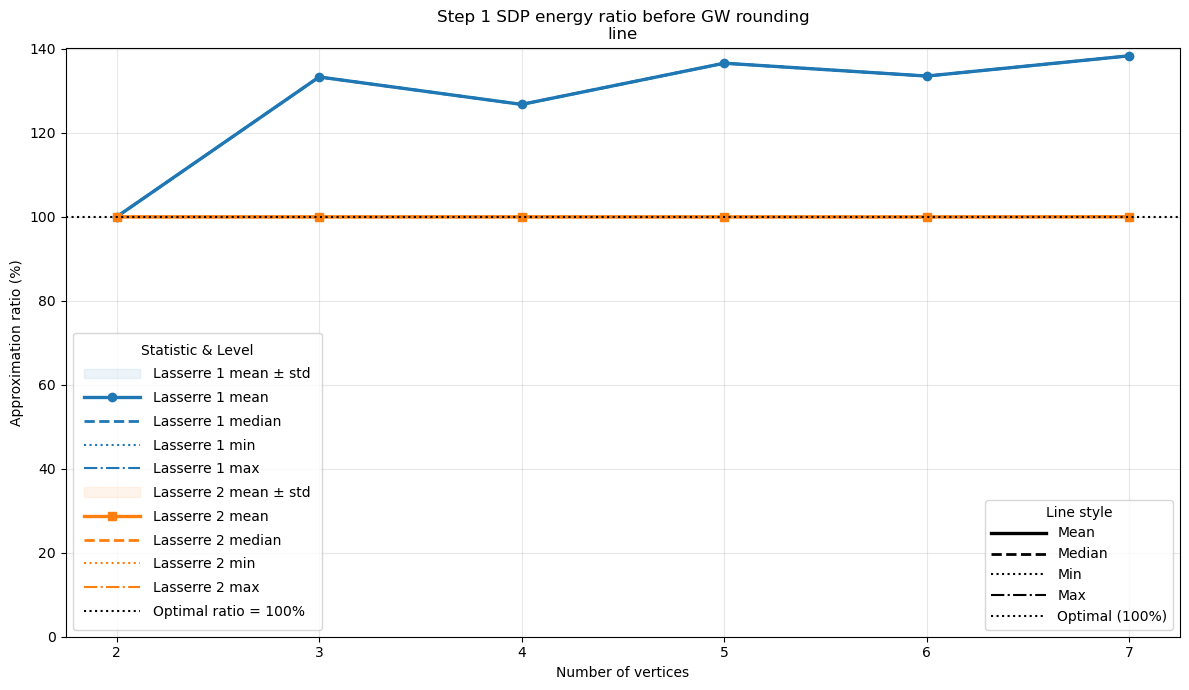

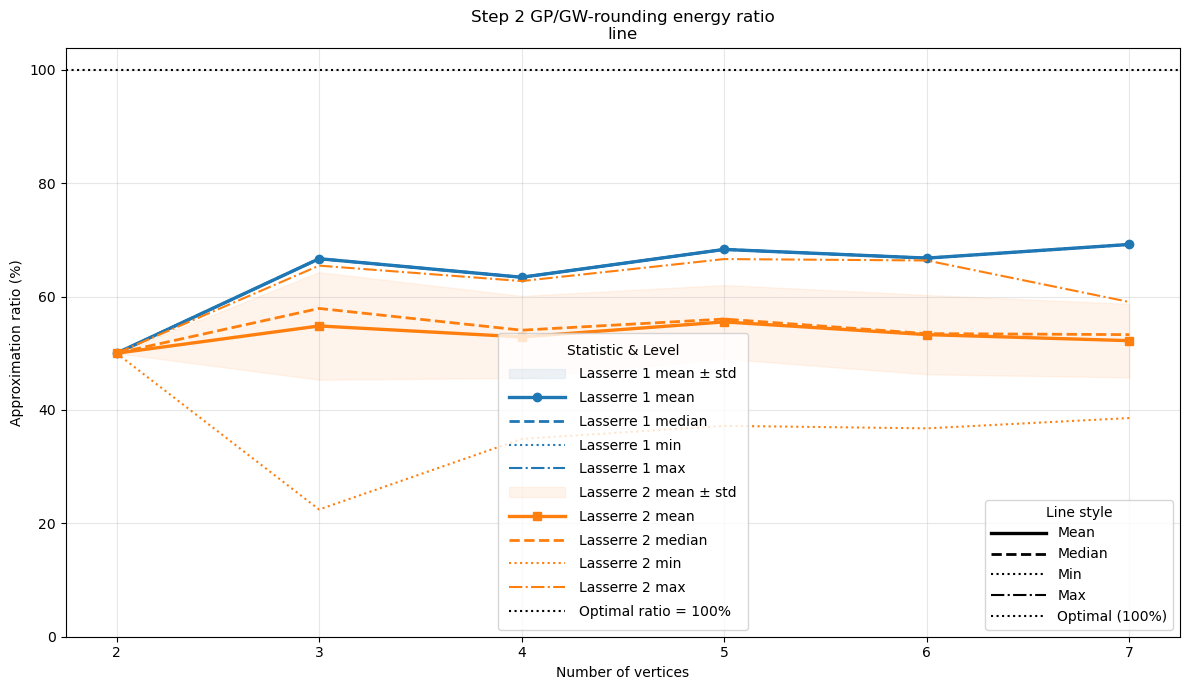

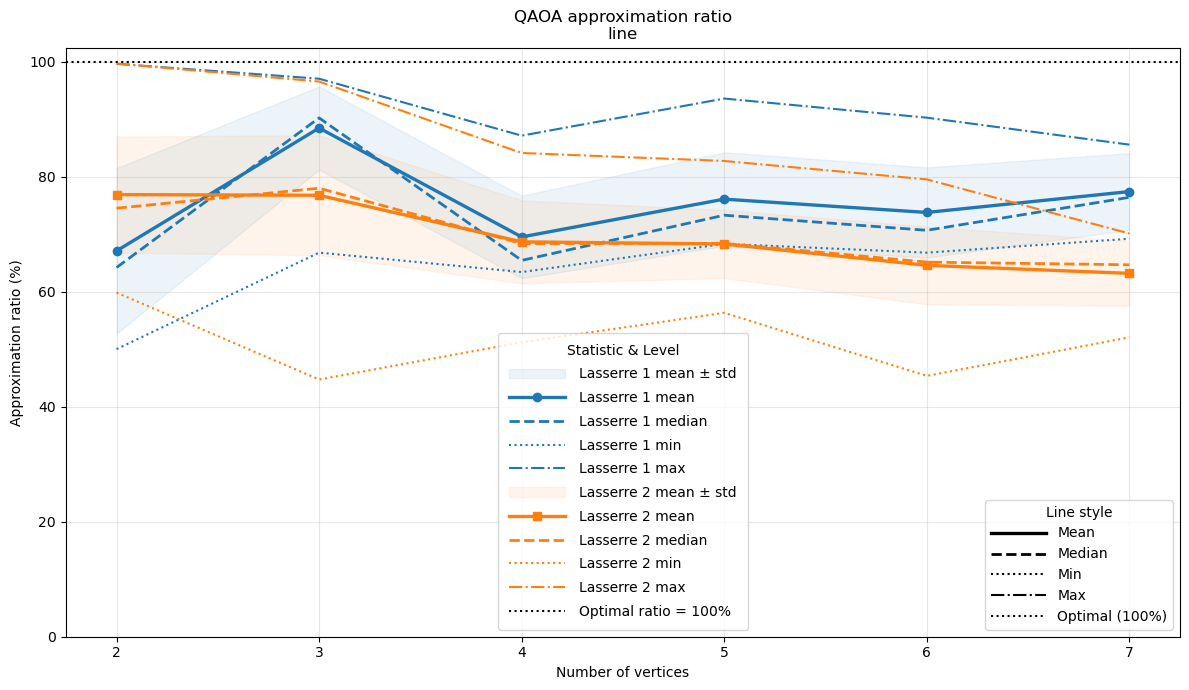

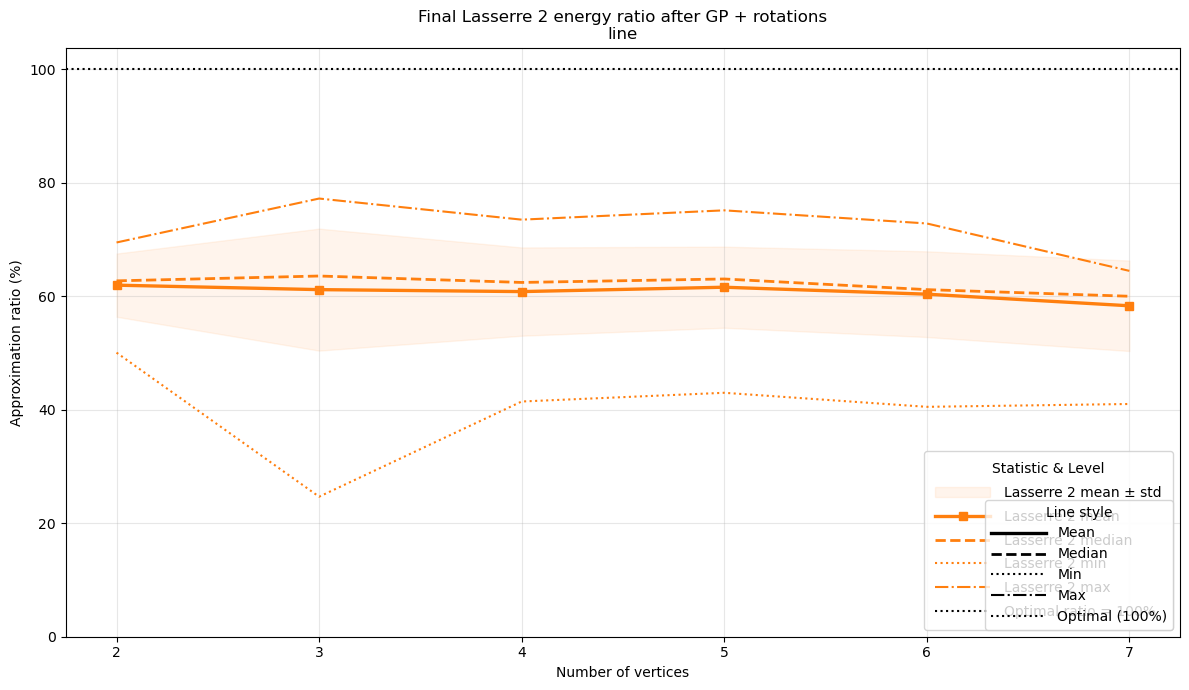

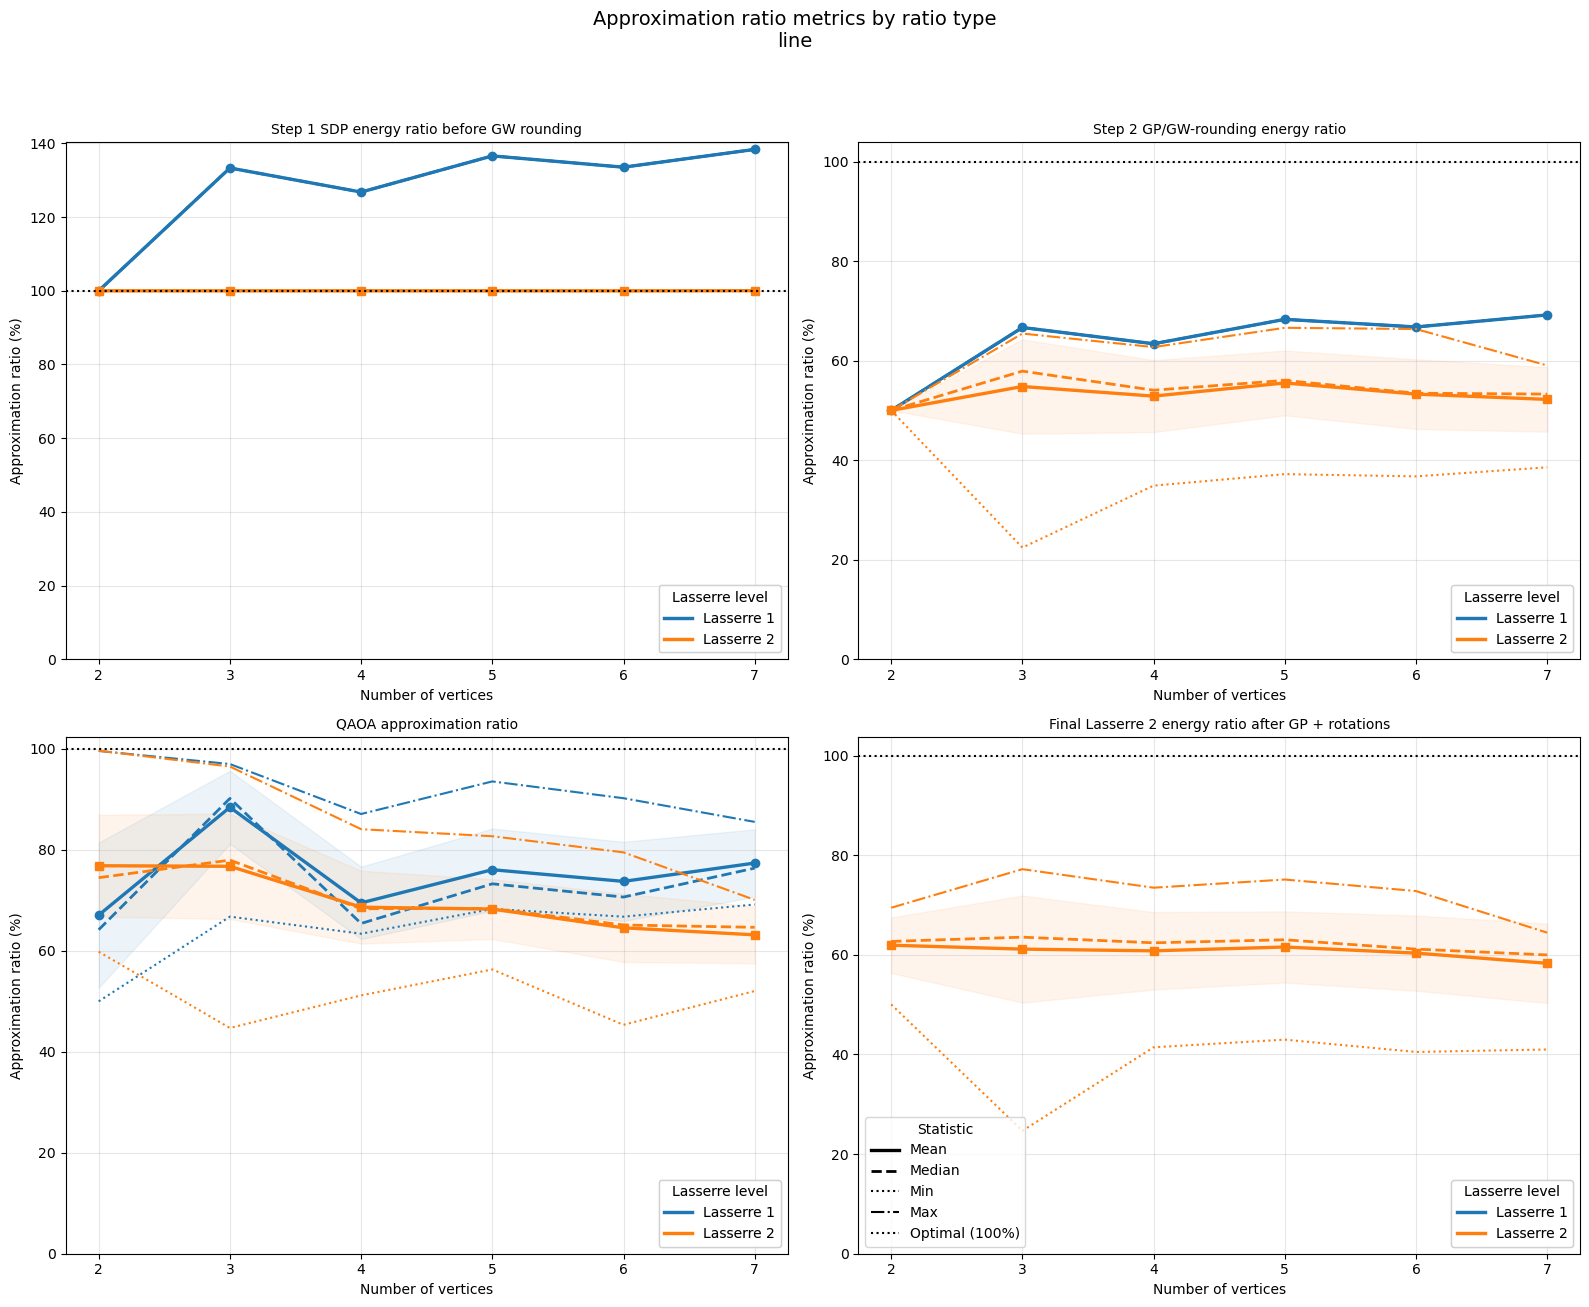

In [21]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D

# -----------------------------
# Plot output options
# -----------------------------
save_ratio_type_plots = False
ratio_type_plot_output_dir = Path("ratio_type_plots")
ratio_type_plot_output_dir.mkdir(exist_ok=True)

# -----------------------------
# Helpers
# -----------------------------
def parse_json_cell(cell):
    if cell is None or pd.isna(cell):
        return {}
    if isinstance(cell, dict):
        return cell
    return json.loads(cell)

def extract_stats(cell):
    """
    Extract min/mean/median/max/std/count from one compact stats cell.
    Values are returned as raw ratios, not percentages.
    """
    payload = parse_json_cell(cell)

    def get_float(key):
        value = payload.get(key)
        if value is None:
            return None
        try:
            return float(value)
        except Exception:
            return None

    return {
        "min": get_float("min"),
        "mean": get_float("mean"),
        "median": get_float("median"),
        "max": get_float("max"),
        "std": get_float("std"),
        "count": payload.get("count", 0),
    }

def extract_graph_info(row):
    return parse_json_cell(row["graph_instance"])

def setting_signature_without_graph_size(graph_info: dict) -> str:
    settings = graph_info.get("settings", {}).copy()
    for key in ["n", "m", "edges", "weights", "edge_weight_dict", "hog_graph_index"]:
        settings.pop(key, None)
    signature_payload = {
        "graph_type": graph_info.get("graph_type") or graph_info.get("type", "unknown"),
        # "settings": settings,  # keep this commented out if you want grouping only by graph_type
    }
    return json.dumps(signature_payload, sort_keys=True)

def short_setting_title(signature: str, max_len: int = 140) -> str:
    payload = json.loads(signature)
    graph_type = payload.get("graph_type", "unknown")
    settings = payload.get("settings", {})

    important_keys = [
        "p",
        "precision/iterations",
        "parameter_vector",
        "optimiser",
        "circuit_type",
        "warm_start_mode",
        "weighted",
    ]
    parts = [f"{k}={settings.get(k)}" for k in important_keys if k in settings]
    title = f"{graph_type}" if not parts else f"{graph_type} | " + ", ".join(parts)
    return title if len(title) <= max_len else title[: max_len - 3] + "..."

def add_stats_columns(df: pd.DataFrame, source_col: str, prefix: str) -> pd.DataFrame:
    stats = df[source_col].apply(extract_stats)
    df[f"{prefix}_min"] = stats.apply(lambda x: x["min"])
    df[f"{prefix}_mean"] = stats.apply(lambda x: x["mean"])
    df[f"{prefix}_median"] = stats.apply(lambda x: x["median"])
    df[f"{prefix}_max"] = stats.apply(lambda x: x["max"])
    df[f"{prefix}_std"] = stats.apply(lambda x: x["std"])
    df[f"{prefix}_count"] = stats.apply(lambda x: x["count"])
    return df

def plot_one_level_with_stats(
    ax,
    group: pd.DataFrame,
    prefix: str,
    label: str,
    color: str,
    mean_linestyle,
    marker: str,
):
    """
    Plot mean, median, min, max (in percentages) plus mean ± std shading for one “level”
    (Lasserre 1 or Lasserre 2). Lines are distinguished by style; colors differentiate L1 vs L2.
    """
    x = group["n_vertices"].astype(int)
    mean = group[f"{prefix}_mean"] * 100
    median = group[f"{prefix}_median"] * 100
    min_y = group[f"{prefix}_min"] * 100
    max_y = group[f"{prefix}_max"] * 100
    std = group[f"{prefix}_std"] * 100

    valid = mean.notna()
    if valid.sum() == 0:
        return False

    x_valid = x[valid]
    mean_valid = mean[valid]
    median_valid = median[valid]
    min_valid = min_y[valid]
    max_valid = max_y[valid]
    std_valid = std[valid]

    # Optional: shade mean ± std band
    if std_valid.notna().any():
        lower = (mean_valid - std_valid).clip(lower=0)
        upper = mean_valid + std_valid
        ax.fill_between(
            x_valid,
            lower,
            upper,
            alpha=0.08,
            color=color,
            label=f"{label} mean ± std",
        )

    # Lines for min, max, mean, median
    # Mean line: same style for both L1 and L2, specified by mean_linestyle
    ax.plot(
        x_valid,
        mean_valid,
        label=f"{label} mean",
        color=color,
        linestyle=mean_linestyle,
        marker=marker,
        linewidth=2.4,
        markersize=6,
    )

    # Median line: dashed
    if median_valid.notna().any():
        ax.plot(
            x_valid,
            median_valid,
            label=f"{label} median",
            color=color,
            linestyle="--",
            marker=None,
            linewidth=2.0,
        )

    # Min line: dotted
    if min_valid.notna().any():
        ax.plot(
            x_valid,
            min_valid,
            label=f"{label} min",
            color=color,
            linestyle=":",
            marker=None,
            linewidth=1.5,
        )

    # Max line: dash-dot
    if max_valid.notna().any():
        ax.plot(
            x_valid,
            max_valid,
            label=f"{label} max",
            color=color,
            linestyle="-.",
            marker=None,
            linewidth=1.5,
        )

    return True

# -----------------------------
# Prepare dataframe
# -----------------------------
plot_df = comparison_df.copy()
plot_df["_graph_info"] = plot_df.apply(extract_graph_info, axis=1)
plot_df["graph_type"] = plot_df["_graph_info"].apply(lambda x: x.get("graph_type") or x.get("type"))
plot_df["n_vertices"] = plot_df["_graph_info"].apply(lambda x: x.get("#vertices") or x.get("n"))
plot_df["n_edges"] = plot_df["_graph_info"].apply(lambda x: x.get("#edges") or x.get("m"))
plot_df["_setting_signature"] = plot_df["_graph_info"].apply(setting_signature_without_graph_size)

plot_df = plot_df[plot_df["graph_type"] == "line"].copy()

if plot_df.empty:
    raise ValueError("No line graph rows found in comparison_df.")

# -----------------------------
# Ratio types: one plot each
# -----------------------------
ratio_type_specs = {
    "step1": {
        "title": "Step 1 SDP energy ratio before GW rounding",
        "l1_col": "Lasserre 1 Step 1 SDP energy approx. ratio (before GW rounding)",
        "l2_col": "Lasserre 2 Step 1 SDP energy approx. ratio (before GW rounding)",
    },
    "gp_rounding": {
        "title": "Step 2 GP/GW-rounding energy ratio",
        "l1_col": "Lasserre 1 Step 2 GP GW-rounding energy approx. ratio",
        "l2_col": "Lasserre 2 Step 2 GP GW-rounding energy approx. ratio",
    },
    "qaoa": {
        "title": "QAOA approximation ratio",
        "l1_col": "Lasserre 1 QAOA approx. ratio",
        "l2_col": "Lasserre 2 QAOA approx. ratio",
    },
    "rotations": {
        "title": "Final Lasserre 2 energy ratio after GP + rotations",
        "l1_col": None,
        "l2_col": "Lasserre 2 Final energy approx. ratio (after GP + rotations)",
    },
}

# -----------------------------
# One plot per ratio type and benchmark setting
# -----------------------------
for setting_idx, (setting_signature, setting_group) in enumerate(plot_df.groupby("_setting_signature"), start=1):
    setting_group = setting_group.sort_values("n_vertices").reset_index(drop=True)

    for ratio_name, ratio_spec in ratio_type_specs.items():
        group = setting_group.copy()

        l1_col = ratio_spec["l1_col"]
        l2_col = ratio_spec["l2_col"]

        has_l1 = l1_col is not None and l1_col in group.columns
        has_l2 = l2_col is not None and l2_col in group.columns

        if not has_l1 and not has_l2:
            print(f"Skipping {ratio_name}: required columns missing.")
            continue

        # Compute stats for L1 and L2 columns
        if has_l1:
            group = add_stats_columns(group, l1_col, "l1")
        if has_l2:
            group = add_stats_columns(group, l2_col, "l2")

        fig, ax = plt.subplots(figsize=(12, 7))

        any_line = False

        # Use same line style for mean across L1 and L2
        if has_l1:
            any_line |= plot_one_level_with_stats(
                ax=ax,
                group=group,
                prefix="l1",
                label="Lasserre 1",
                color="tab:blue",
                mean_linestyle="-",
                marker="o",
            )

        if has_l2:
            any_line |= plot_one_level_with_stats(
                ax=ax,
                group=group,
                prefix="l2",
                label="Lasserre 2",
                color="tab:orange",
                mean_linestyle="-",
                marker="s",
            )

        if not any_line:
            print(f"Skipping {ratio_name}: no numeric ratio values available.")
            plt.close(fig)
            continue

        ax.axhline(
            100.0,
            linestyle=":",
            linewidth=1.5,
            color="black",
            label="Optimal ratio = 100%",
        )

        title = short_setting_title(setting_signature)
        ax.set_title(f"{ratio_spec['title']}\n{title}")
        ax.set_xlabel("Number of vertices")
        ax.set_ylabel("Approximation ratio (%)")
        ax.set_ylim(bottom=0)

        unique_x = sorted(group["n_vertices"].dropna().astype(int).unique())
        ax.set_xticks(unique_x)
        ax.grid(True, alpha=0.3)

        # Build legends
        # Main legend: all plotted lines (handles from ax.plot / fill_between)
        handles, labels = ax.get_legend_handles_labels()
        # Style legend: show line styles for Mean, Median, Min, Max
        style_handles = [
            Line2D([0], [0], color="black", linestyle="-", linewidth=2.4, label="Mean"),
            Line2D([0], [0], color="black", linestyle="--", linewidth=2.0, label="Median"),
            Line2D([0], [0], color="black", linestyle=":", linewidth=1.5, label="Min"),
            Line2D([0], [0], color="black", linestyle="-.", linewidth=1.5, label="Max"),
            Line2D([0], [0], color="black", linestyle=":", linewidth=1.5, label="Optimal (100%)"),
        ]

        main_legend = ax.legend(handles=handles, loc="best", handlelength=4.0, handletextpad=1.0, borderpad=0.8, labelspacing=0.7, title="Statistic & Level")
        ax.add_artist(main_legend)

        ax.legend(
            handles=style_handles,
            loc="lower right",
            handlelength=4.0,
            title="Line style",
        )

        plt.tight_layout()

        if save_ratio_type_plots:
            filename = f"ratio_type_{ratio_name}_setting_{setting_idx:03d}.png"
            path = ratio_type_plot_output_dir / filename
            fig.savefig(path, dpi=200, bbox_inches="tight")
            print(f"Saved: {path}")

        plt.show()

# -----------------------------
# Combined plot: 4 ratio types per benchmark setting
# -----------------------------
for setting_idx, (setting_signature, setting_group) in enumerate(plot_df.groupby("_setting_signature"), start=1):
    setting_group = setting_group.sort_values("n_vertices").reset_index(drop=True)

    # Create a 2x2 figure for all ratio types
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    ratio_order = ["step1", "gp_rounding", "qaoa", "rotations"]
    for idx, ratio_name in enumerate(ratio_order):
        row_idx, col_idx = divmod(idx, 2)
        ax = axes[row_idx][col_idx]

        ratio_spec = ratio_type_specs.get(ratio_name, {})
        l1_col = ratio_spec.get("l1_col")
        l2_col = ratio_spec.get("l2_col")

        group = setting_group.copy()
        has_l1 = l1_col is not None and l1_col in group.columns
        has_l2 = l2_col is not None and l2_col in group.columns

        if has_l1:
            group = add_stats_columns(group, l1_col, "l1")
        if has_l2:
            group = add_stats_columns(group, l2_col, "l2")

        any_line = False
        if has_l1:
            any_line |= plot_one_level_with_stats(
                ax=ax,
                group=group,
                prefix="l1",
                label="Lasserre 1",
                color="tab:blue",
                mean_linestyle="-",
                marker="o",
            )
        if has_l2:
            any_line |= plot_one_level_with_stats(
                ax=ax,
                group=group,
                prefix="l2",
                label="Lasserre 2",
                color="tab:orange",
                mean_linestyle="-",
                marker="s",
            )

        # Add horizontal line at 100%
        ax.axhline(
            100.0,
            linestyle=":",
            linewidth=1.5,
            color="black",
            label="Optimal (100%)",
        )

        ax.set_xlabel("Number of vertices")
        ax.set_ylabel("Approximation ratio (%)")
        ax.set_ylim(bottom=0)
        unique_x = sorted(group["n_vertices"].dropna().astype(int).unique())
        ax.set_xticks(unique_x)
        ax.grid(True, alpha=0.3)

        # Title for each subplot
        ax.set_title(ratio_type_specs[ratio_name]["title"], fontsize=10)

        # Style legend: same for all subplots
        if idx == len(ratio_order) - 1:
            style_legend = ax.legend(handles=style_handles, loc="lower left", title="Statistic")

            ax.add_artist(style_legend)
        color_legend = ax.legend(handles=color_handles, loc="lower right", title="Lasserre level")
        ax.add_artist(color_legend)
    # Top title for combined figure
    combined_title = short_setting_title(setting_signature)
    fig.suptitle(f"Approximation ratio metrics by ratio type\n{combined_title}", fontsize=14)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

Number of plot groups: 1
  graph_type  n_vertices  n_edges         _setting_signature
0       line           2        1  {"graph_type": "unknown"}
1       line           3        2  {"graph_type": "unknown"}
2       line           4        3  {"graph_type": "unknown"}
3       line           5        4  {"graph_type": "unknown"}
4       line           6        5  {"graph_type": "unknown"}
5       line           7        6  {"graph_type": "unknown"}


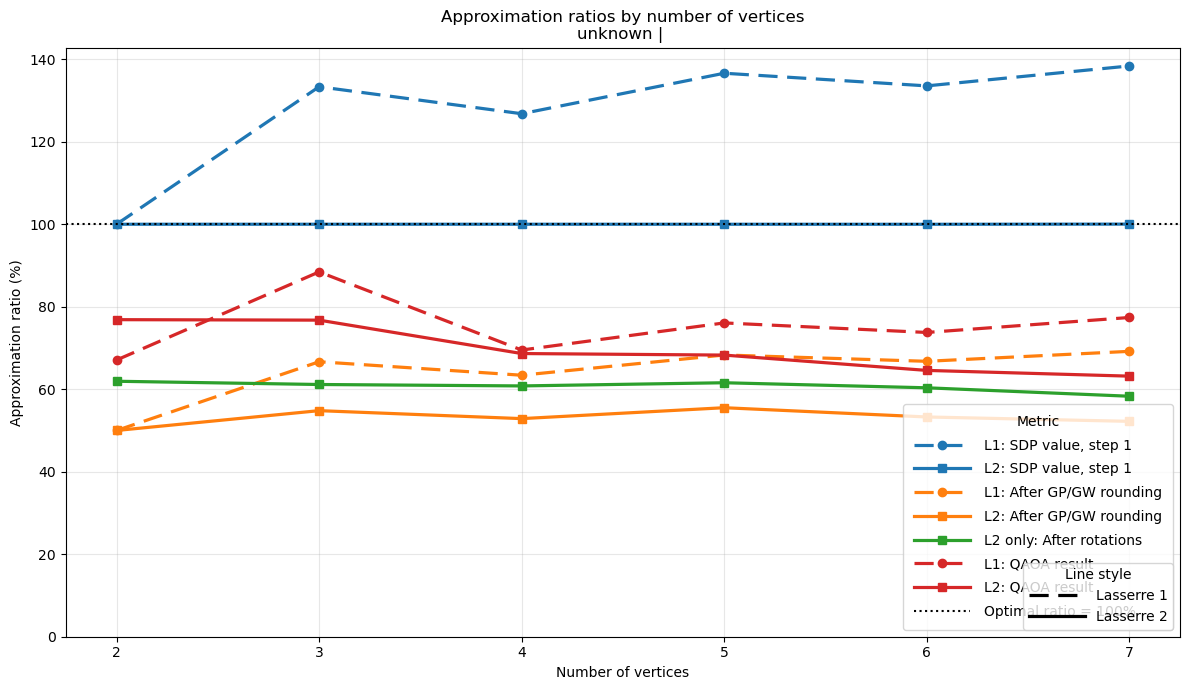

In [22]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D


# -----------------------------
# Plot output options
# -----------------------------
save_plots = False
plot_output_dir = Path("ratio_plots")
plot_output_dir.mkdir(exist_ok=True)


# -----------------------------
# Helpers
# -----------------------------
def parse_json_cell(cell):
    if cell is None or pd.isna(cell):
        return {}
    if isinstance(cell, dict):
        return cell
    return json.loads(cell)


def extract_stat(cell, stat="mean"):
    payload = parse_json_cell(cell)
    value = payload.get(stat)
    if value is None:
        return None
    try:
        return float(value)
    except Exception:
        return None


def extract_graph_info(row):
    return parse_json_cell(row["graph_instance"])


def setting_signature_without_graph_size(graph_info: dict) -> str:
    """
    One benchmark setting = same graph type and same algorithmic settings.
    n/m/edges vary along the x-axis.
    """
    settings = graph_info.get("settings", {}).copy()

    for key in [
        "n",
        "m",
        "edges",
        "weights",
        "edge_weight_dict",
        "hog_graph_index",
    ]:
        settings.pop(key, None)

    signature_payload = {
        "graph_type": graph_info.get("type", "unknown"),
        #"settings": settings,
    }

    return json.dumps(signature_payload, sort_keys=True)


def short_setting_title(signature: str, max_len: int = 140) -> str:
    payload = json.loads(signature)

    graph_type = payload.get("graph_type", "unknown")
    settings = payload.get("settings", {})

    important_keys = [
        "p",
        "precision/iterations",
        "parameter_vector",
        "optimiser",
        "circuit_type",
        "warm_start_mode",
        "weighted",
    ]

    parts = [f"{k}={settings.get(k)}" for k in important_keys if k in settings]
    title = f"{graph_type} | " + ", ".join(parts)

    if len(title) > max_len:
        title = title[:max_len - 3] + "..."

    return title


# -----------------------------
# Prepare plotting dataframe
# -----------------------------
plot_df = comparison_df.copy()

plot_df["_graph_info"] = plot_df.apply(extract_graph_info, axis=1)
plot_df["graph_type"] = plot_df["_graph_info"].apply(lambda x: x.get("graph_type"))
plot_df["n_vertices"] = plot_df["_graph_info"].apply(lambda x: x.get("#vertices"))
plot_df["n_edges"] = plot_df["_graph_info"].apply(lambda x: x.get("#edges"))

# Correct: one setting can contain several n values.
plot_df["_setting_signature"] = plot_df["_graph_info"].apply(setting_signature_without_graph_size)

# For now only line graphs.
plot_df = plot_df[plot_df["graph_type"] == "line"].copy()

if plot_df.empty:
    raise ValueError("No line graph rows found in comparison_df.")

print("Number of plot groups:", plot_df["_setting_signature"].nunique())
print(
    plot_df[["graph_type", "n_vertices", "n_edges", "_setting_signature"]]
    .drop_duplicates()
    .sort_values(["n_vertices", "n_edges"])
)


# -----------------------------
# Ratio columns to plot
# -----------------------------
ratio_specs = {
    "step1_l1": {
        "column": "Lasserre 1 Step 1 SDP energy approx. ratio (before GW rounding)",
        "label": "SDP value, step 1",
        "level": "L1",
        "color": "tab:blue",
        "linestyle": (0, (6, 3)),   # visibly dashed
        "marker": "o",
    },
    "step1_l2": {
        "column": "Lasserre 2 Step 1 SDP energy approx. ratio (before GW rounding)",
        "label": "SDP value, step 1",
        "level": "L2",
        "color": "tab:blue",
        "linestyle": "-",
        "marker": "s",
    },
    "rounding_l1": {
        "column": "Lasserre 1 Step 2 GP GW-rounding energy approx. ratio",
        "label": "After GP/GW rounding",
        "level": "L1",
        "color": "tab:orange",
        "linestyle": (0, (6, 3)),
        "marker": "o",
    },
    "rounding_l2": {
        "column": "Lasserre 2 Step 2 GP GW-rounding energy approx. ratio",
        "label": "After GP/GW rounding",
        "level": "L2",
        "color": "tab:orange",
        "linestyle": "-",
        "marker": "s",
    },
    "rotations_l2": {
        "column": "Lasserre 2 Final energy approx. ratio (after GP + rotations)",
        "label": "After rotations",
        "level": "L2 only",
        "color": "tab:green",
        "linestyle": "-",
        "marker": "s",
    },
    "qaoa_l1": {
        "column": "Lasserre 1 QAOA approx. ratio",
        "label": "QAOA result",
        "level": "L1",
        "color": "tab:red",
        "linestyle": (0, (6, 3)),
        "marker": "o",
    },
    "qaoa_l2": {
        "column": "Lasserre 2 QAOA approx. ratio",
        "label": "QAOA result",
        "level": "L2",
        "color": "tab:red",
        "linestyle": "-",
        "marker": "s",
    },
}

for spec in ratio_specs.values():
    col = spec["column"]
    out_col = col + "_mean"

    if col in plot_df.columns:
        plot_df[out_col] = plot_df[col].apply(lambda cell: extract_stat(cell, "mean"))
    else:
        plot_df[out_col] = None


# -----------------------------
# One plot per benchmark setting
# -----------------------------
for setting_idx, (setting_signature, group) in enumerate(plot_df.groupby("_setting_signature"), start=1):
    group = group.sort_values("n_vertices").reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(12, 7))

    x = group["n_vertices"].astype(int)
    any_line = False

    for _, spec in ratio_specs.items():
        y_col = spec["column"] + "_mean"
        y = group[y_col] * 100

        valid = y.notna()
        if valid.sum() == 0:
            continue

        any_line = True

        full_label = f"{spec['level']}: {spec['label']}"

        ax.plot(
            x[valid],
            y[valid],
            label=full_label,
            color=spec["color"],
            linestyle=spec["linestyle"],
            marker=spec["marker"],
            linewidth=2.3,
            markersize=6,
        )

    if not any_line:
        print(f"Skipping setting {setting_idx}: no ratio values available.")
        plt.close(fig)
        continue

    ax.axhline(
        100.0,
        linestyle=":",
        linewidth=1.5,
        color="black",
        label="Optimal ratio = 100%",
    )

    title = short_setting_title(setting_signature)
    ax.set_title(f"Approximation ratios by number of vertices\n{title}")
    ax.set_xlabel("Number of vertices")
    ax.set_ylim(bottom=0)
    ax.set_ylabel("Approximation ratio (%)")

    unique_x = sorted(group["n_vertices"].dropna().astype(int).unique())
    ax.set_xticks(unique_x)

    ax.grid(True, alpha=0.3)

    # Main legend: actual plotted lines.
    main_legend = ax.legend(
        loc="best",
        handlelength=4.0,     # makes dashed lines visible
        handletextpad=1.0,
        borderpad=0.8,
        labelspacing=0.7,
        title="Metric",
    )
    ax.add_artist(main_legend)

    # Extra legend: visual rule for line styles.
    style_handles = [
        Line2D([0], [0], color="black", linestyle=(0, (6, 3)), linewidth=2.3, label="Lasserre 1"),
        Line2D([0], [0], color="black", linestyle="-", linewidth=2.3, label="Lasserre 2"),
    ]

    ax.legend(
        handles=style_handles,
        loc="lower right",
        handlelength=4.0,
        title="Line style",
    )

    plt.tight_layout()

    if save_plots:
        filename = f"ratio_plot_setting_{setting_idx:03d}.png"
        path = plot_output_dir / filename
        fig.savefig(path, dpi=200, bbox_inches="tight")
        print(f"Saved: {path}")

    plt.show()

NameError: name 'label' is not defined

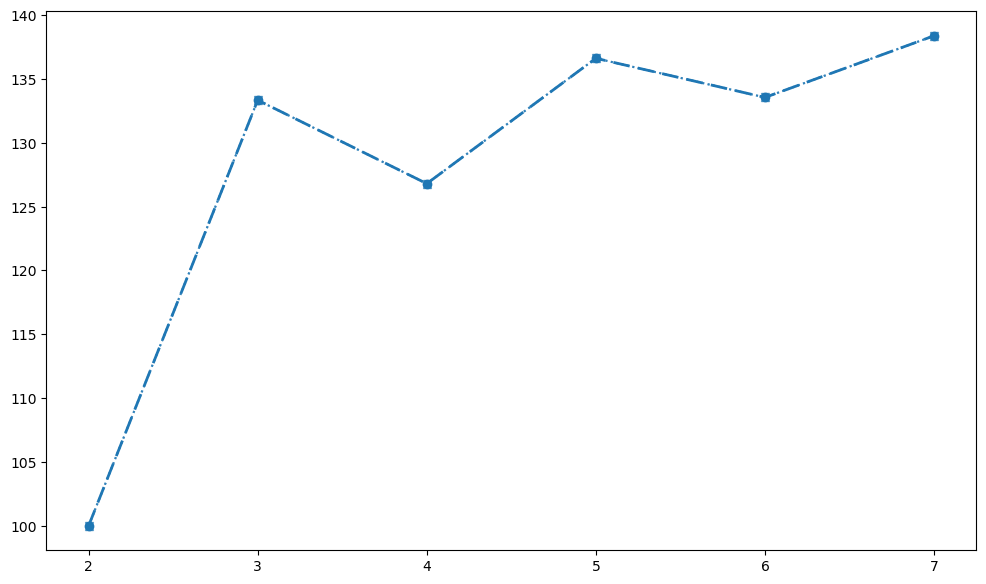

In [23]:
import json
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# -----------------------------
# Helpers (same as before)
# -----------------------------
def parse_json_cell(cell):
    if cell is None or pd.isna(cell):
        return {}
    if isinstance(cell, dict):
        return cell
    return json.loads(cell)

def extract_stat(cell, stat="mean"):
    payload = parse_json_cell(cell)
    value = payload.get(stat)
    return float(value) if value is not None else None

def extract_graph_info(row):
    return parse_json_cell(row["graph_instance"])

# Keep only line graphs for this plotting
plot_df = comparison_df.copy()
plot_df["_graph_info"] = plot_df.apply(extract_graph_info, axis=1)
plot_df["graph_type"] = plot_df["_graph_info"].apply(lambda x: x.get("graph_type"))
plot_df = plot_df[plot_df["graph_type"] == "line"].copy()

# Extract n_vertices
plot_df["n_vertices"] = plot_df["_graph_info"].apply(lambda x: x.get("#vertices"))

# Define your ratio specs: one entry per ratio type (same as earlier)
ratio_specs = {
    "step1": {
        "column": "Lasserre 1 Step 1 SDP energy approx. ratio (before GW rounding)",
        "column2": "Lasserre 2 Step 1 SDP energy approx. ratio (before GW rounding)",
        "title": "Step 1 SDP approximation ratio (before GW rounding)",
        "color": "tab:blue",
    },
    "rounding": {
        "column": "Lasserre 1 Step 2 GP GW-rounding energy approx. ratio",
        "column2": "Lasserre 2 Step 2 GP GW-rounding energy approx. ratio",
        "title": "Step 2 GP/GW rounding approximation ratio",
        "color": "tab:orange",
    },
    "rotations": {
        "column": None,  # no Lasserre 1 equivalent for this stage
        "column2": "Lasserre 2 Final energy approx. ratio (after GP + rotations)",
        "title": "Step 2 after rotations approximation ratio (L2 only)",
        "color": "tab:green",
    },
    "qaoa": {
        "column": "Lasserre 1 QAOA approx. ratio",
        "column2": "Lasserre 2 QAOA approx. ratio",
        "title": "QAOA approximation ratio",
        "color": "tab:red",
    },
}

# Extract statistics columns for each ratio type
stats = ["min", "mean", "median", "max", "std"]
for spec_key, spec in ratio_specs.items():
    for level_name, col_name in zip(["L1", "L2"], [spec["column"], spec["column2"]]):
        if col_name:
            for stat in stats:
                new_col = f"{col_name}_{stat}"
                plot_df[new_col] = plot_df[col_name].apply(lambda cell, s=stat: extract_stat(cell, s))

# Plot each ratio type separately
for spec_key, spec in ratio_specs.items():
    fig, ax = plt.subplots(figsize=(12, 7))
    has_data = False

    # Loop over each Lasserre level separately (L1 and L2)
    for level_name, col_name, style in [
        ("L1", spec.get("column"), (0, (6, 3))),  # dashed
        ("L2", spec.get("column2"), "-"),        # solid
    ]:
        if not col_name:
            # skip L1 if there is no L1 equivalent for this ratio type
            continue

        # Extract stats for this level
        grouped = plot_df[plot_df[col_name].notna()].sort_values("n_vertices")

        if grouped.empty:
            continue

        x = grouped["n_vertices"].astype(int)

        # Plot min, median, mean, and max individually
        y_min = grouped[f"{col_name}_min"] * 100
        y_median = grouped[f"{col_name}_median"] * 100
        y_mean = grouped[f"{col_name}_mean"] * 100
        y_max = grouped[f"{col_name}_max"] * 100
        y_std = grouped[f"{col_name}_std"] * 100

        # Plot min/max as dotted lines
        ax.plot(x, y_min, linestyle=":", color=spec["color"], alpha=0.7,
                marker="v", label=f"{spec['title']} {level_name} min")
        ax.plot(x, y_max, linestyle=":", color=spec["color"], alpha=0.7,
                marker="^", label=f"{spec['title']} {level_name} max")

        # Plot mean and median with thicker lines and specified style
        ax.plot(
            x,
            y_mean,
            label=f"{spec['title']} {level_name} mean",
            color=spec["color"],
            linestyle=style,
            marker="o",
            linewidth=2.0,
        )
        ax.plot(
            x,
            y_median,
            label(f"{spec['title']} {level_name} median"),
            color=spec["color"],
            linestyle=style,
            marker="s",
            linewidth=2.0,
        )

        # Shade ±std around mean
        lower = y_mean - y_std
        upper = y_mean + y_std
        ax.fill_between(
            x,
            lower,
            upper,
            alpha=0.15,
            color=spec["color"],
        )

        has_data = True

    if not has_data:
        plt.close(fig)
        continue

    ax.axhline(100.0, color="black", linestyle=":", linewidth=1.5, label="Optimal ratio = 100%")
    ax.set_xlabel("Number of vertices")
    ax.set_ylabel("Approximation ratio (%)")
    ax.set_ylim(bottom=0)
    ax.set_xticks(sorted(plot_df["n_vertices"].dropna().astype(int).unique()))
    ax.set_title(spec["title"])

    # Arrange the legend properly
    ax.legend(loc="best", handlelength=3.0)

    plt.grid(alpha=0.3)
    plt.tight_layout()

    # Uncomment to save plots to disk
    # fig.savefig(plot_output_dir / f"ratio_{spec_key}.png", dpi=200)

    plt.show()

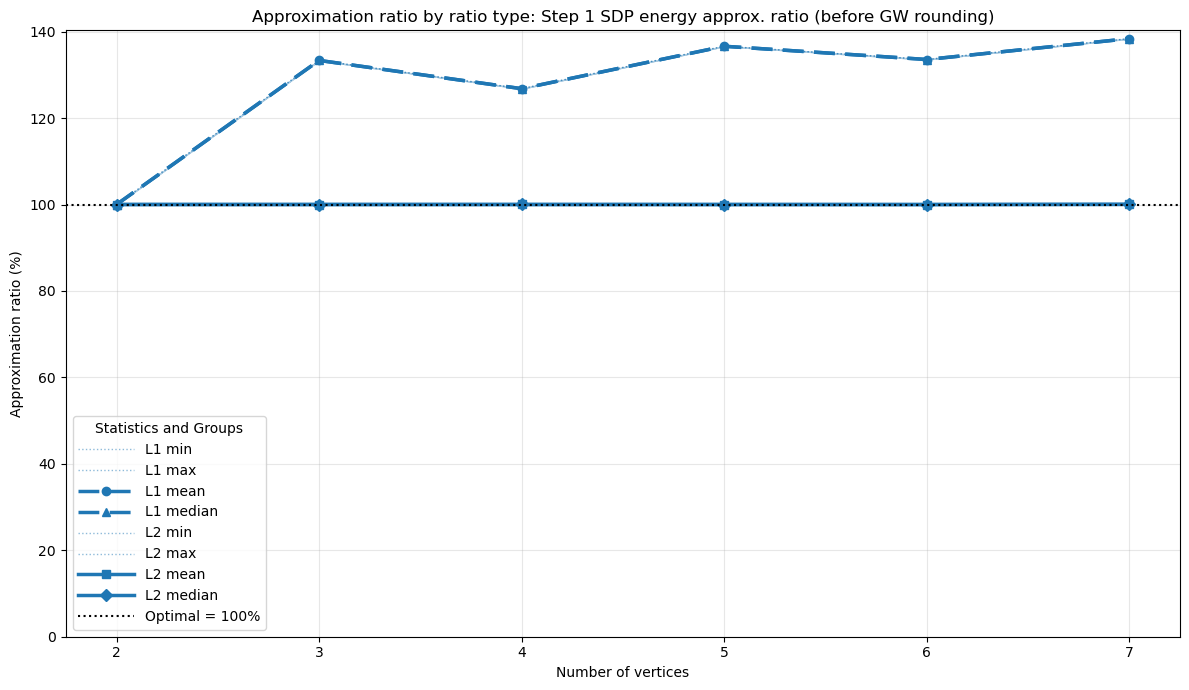

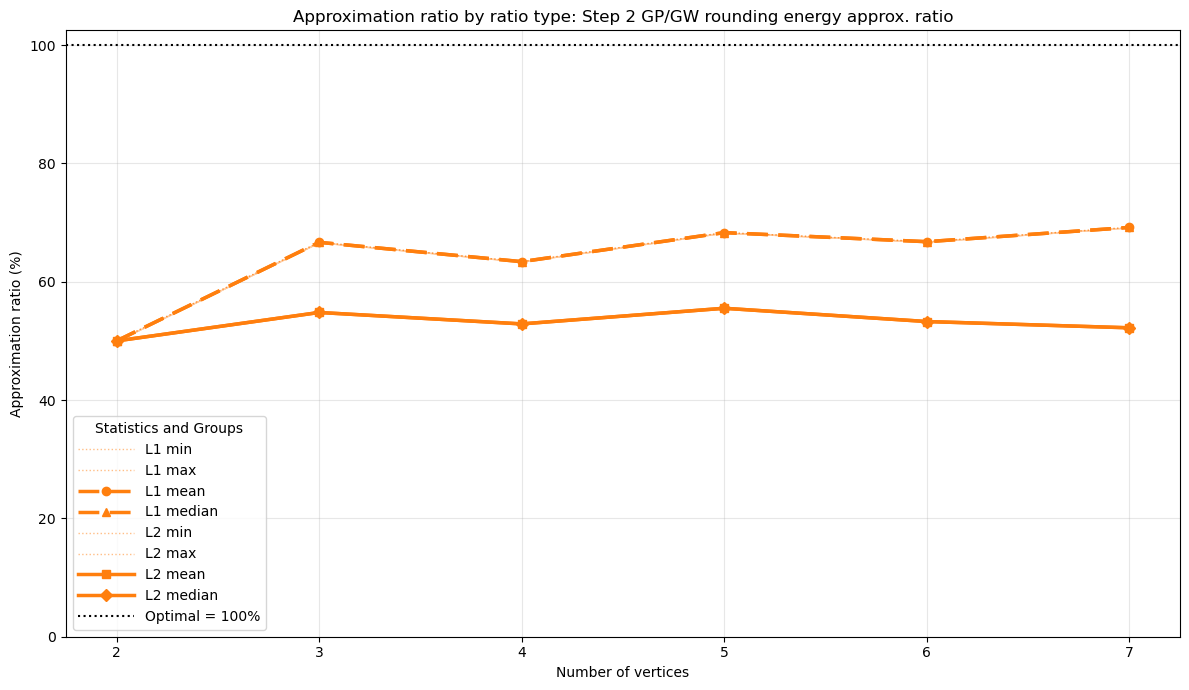

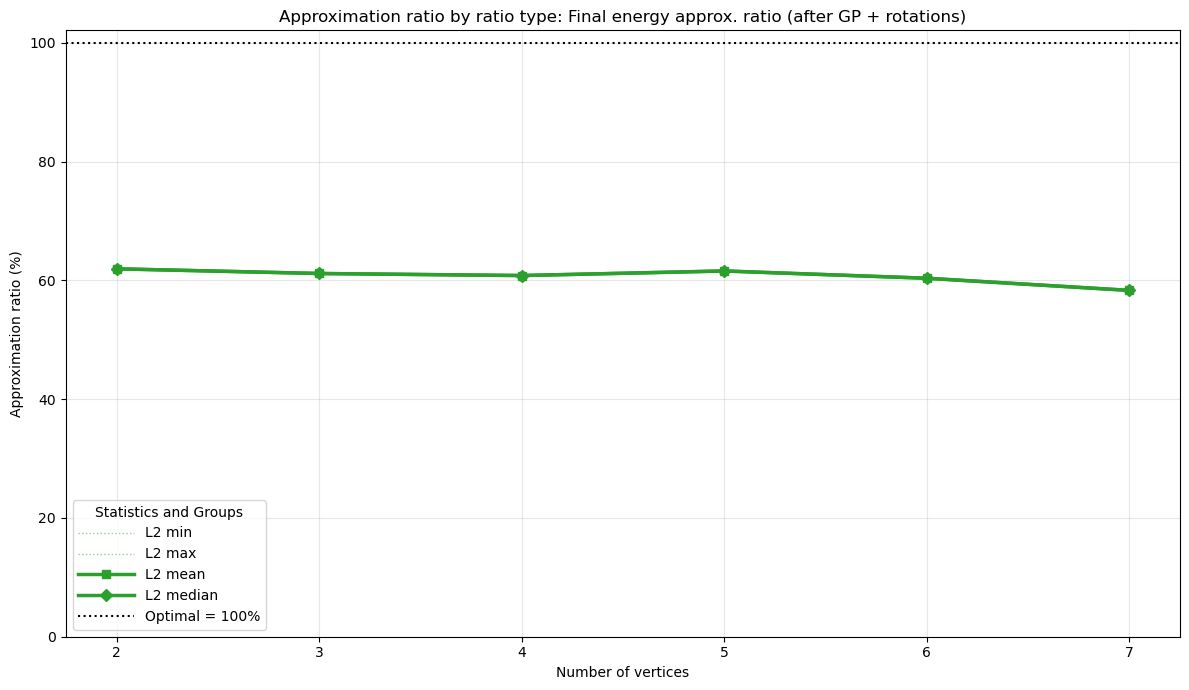

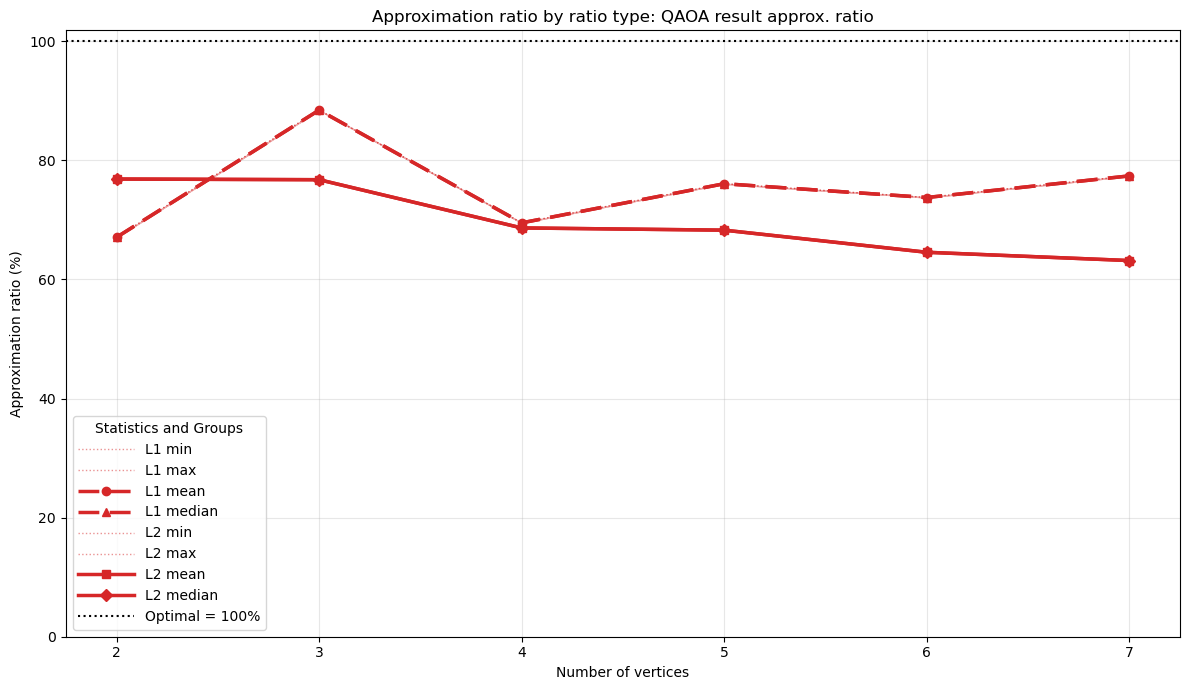

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd

# Helper functions to parse JSON-like cells and extract stats
def parse_json_cell(cell):
    if cell is None or pd.isna(cell):
        return {}
    if isinstance(cell, dict):
        return cell
    return json.loads(cell)

def extract_stat(cell, stat="mean"):
    payload = parse_json_cell(cell)
    value = payload.get(stat)
    if value is None:
        return None
    try:
        return float(value)
    except Exception:
        return None

# Extract graph info for grouping
def extract_graph_info(row):
    return parse_json_cell(row["graph_instance"])

# Prepare dataframe with numeric graph fields
plot_df = comparison_df.copy()
plot_df["_graph_info"] = plot_df.apply(extract_graph_info, axis=1)
plot_df["graph_type"] = plot_df["_graph_info"].apply(lambda x: x.get("graph_type"))
plot_df["n_vertices"] = plot_df["_graph_info"].apply(lambda x: x.get("#vertices"))
plot_df["n_edges"] = plot_df["_graph_info"].apply(lambda x: x.get("#edges"))

# We will only plot line graphs here
plot_df = plot_df[plot_df["graph_type"] == "line"].copy()
if plot_df.empty:
    raise ValueError("No line graph rows found in comparison_df.")

# Define ratio types with their L1/L2 columns and a base color
ratio_types = [
    {
        "ratio_key": "step1",
        "title": "Step 1 SDP energy approx. ratio (before GW rounding)",
        "columns": {
            "L1": "Lasserre 1 Step 1 SDP energy approx. ratio (before GW rounding)",
            "L2": "Lasserre 2 Step 1 SDP energy approx. ratio (before GW rounding)",
        },
        "color": "tab:blue",
    },
    {
        "ratio_key": "gp_rounding",
        "title": "Step 2 GP/GW rounding energy approx. ratio",
        "columns": {
            "L1": "Lasserre 1 Step 2 GP GW-rounding energy approx. ratio",
            "L2": "Lasserre 2 Step 2 GP GW-rounding energy approx. ratio",
        },
        "color": "tab:orange",
    },
    {
        "ratio_key": "rotations",
        "title": "Final energy approx. ratio (after GP + rotations)",
        "columns": {
            "L2": "Lasserre 2 Final energy approx. ratio (after GP + rotations)",
        },
        "color": "tab:green",
    },
    {
        "ratio_key": "qaoa",
        "title": "QAOA result approx. ratio",
        "columns": {
            "L1": "Lasserre 1 QAOA approx. ratio",
            "L2": "Lasserre 2 QAOA approx. ratio",
        },
        "color": "tab:red",
    },
]

# Convert ratio columns to mean/median/min/max/std columns in numeric form
for ratio in ratio_types:
    for level, col in ratio["columns"].items():
        for stat in ["min", "mean", "median", "max", "std"]:
            out_col = f"{col}_{stat}"
            plot_df[out_col] = plot_df[col].apply(lambda cell: extract_stat(cell, stat))
            
# Convert ratio values to percentages (0–100) after extraction
def to_percent(series):
    return series.astype(float) * 100

# Generate one plot per ratio type
for ratio in ratio_types:
    ratio_title = ratio["title"]
    base_color = ratio["color"]
    fig, ax = plt.subplots(figsize=(12, 7))

    for level in ["L1", "L2"]:
        if level not in ratio["columns"]:
            continue

        col_name = ratio["columns"][level]
        # Extract per-stat series for this ratio column
        df_level = plot_df.copy()
        n_values = df_level["n_vertices"].astype(int)

        # We may have multiple rows for the same n_vertices; aggregate them by averaging stats per n
        # Group by n
        grouped = df_level.groupby(n_values)
        aggregated = {
            "n_vertices": [],
            "min": [],
            "mean": [],
            "median": [],
            "max": [],
            "std": [],
        }
        for n, group in grouped:
            aggregated["n_vertices"].append(n)
            # Average across rows for mean and median, min of mins, max of maxes, avg std
            aggregated["min"].append(group[f"{col_name}_min"].mean())
            aggregated["mean"].append(group[f"{col_name}_mean"].mean())
            aggregated["median"].append(group[f"{col_name}_median"].mean())
            aggregated["max"].append(group[f"{col_name}_max"].mean())
            aggregated["std"].append(group[f"{col_name}_std"].mean())

        # Convert to percentages
        n_vals = np.array(aggregated["n_vertices"])
        y_min = to_percent(pd.Series(aggregated["min"]))
        y_mean = to_percent(pd.Series(aggregated["mean"]))
        y_median = to_percent(pd.Series(aggregated["median"]))
        y_max = to_percent(pd.Series(aggregated["max"]))
        y_std = to_percent(pd.Series(aggregated["std"]))

        # Define style based on level (L1 vs L2)
        linestyle = (0, (6, 3)) if level == "L1" else "-"
        label_prefix = "L1" if level == "L1" else "L2"

        # Shade the full min–max range
        ax.fill_between(
            n_vals,
            y_min,
            y_max,
            color=base_color,
            alpha=0.15,
        )
        # Shade ±std around mean
        ax.fill_between(
            n_vals,
            y_mean - y_std,
            y_mean + y_std,
            color=base_color,
            alpha=0.25,
        )

        # Plot min and max as thin lines (semi-transparent)
        ax.plot(
            n_vals,
            y_min,
            linestyle=":",
            linewidth=1.0,
            color=base_color,
            alpha=0.5,
            label=f"{label_prefix} min",
        )
        ax.plot(
            n_vals,
            y_max,
            linestyle=":",
            linewidth=1.0,
            color=base_color,
            alpha=0.5,
            label=f"{label_prefix} max",
        )

        # Plot mean and median with thicker lines
        ax.plot(
            n_vals,
            y_mean,
            linestyle=linestyle,
            linewidth=2.5,
            color=base_color,
            marker="o" if level == "L1" else "s",
            label=f"{label_prefix} mean",
        )
        ax.plot(
            n_vals,
            y_median,
            linestyle=linestyle,
            linewidth=2.5,
            color=base_color,
            marker="^" if level == "L1" else "D",
            label=f"{label_prefix} median",
        )

    # Add horizontal line at 100% for the optimum
    ax.axhline(100.0, color="black", linestyle=":", linewidth=1.5, label="Optimal = 100%")

    # Set axes and title
    ax.set_xlabel("Number of vertices")
    ax.set_ylabel("Approximation ratio (%)")
    ax.set_title(f"Approximation ratio by ratio type: {ratio_title}")
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(sorted(plot_df["n_vertices"].astype(int).unique()))

    # Combine handles to avoid duplicate labels
    handles, labels = ax.get_legend_handles_labels()
    unique_labels = {}
    for h, l in zip(handles, labels):
        if l not in unique_labels:
            unique_labels[l] = h
    ax.legend(
        unique_labels.values(),
        unique_labels.keys(),
        loc="best",
        handlelength=4.0,
        title="Statistics and Groups",
    )

    plt.tight_layout()
    plt.show()